# Fase 3 - Modelo clasico: Random Forest

En esta fase se entrena un modelo clasico de Machine Learning para el problema de clasificacion binaria del dataset Adult / Census Income.

El objetivo es predecir si una persona gana `<=50K` o `>50K` al anio. La variable objetivo ya esta codificada como:

- `0`: <=50K
- `1`: >50K

Se utiliza Random Forest porque es un modelo clasico adecuado para datos tabulares y permite comparar sus resultados contra los modelos de redes neuronales de la Fase 2.

## 1. Importar librerias

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV

sns.set(style="whitegrid")

## 2. Cargar los datos procesados

Se usan directamente los archivos generados en la Fase 1. No se repite el preprocesamiento ni se hace un nuevo train_test_split, lo que garantiza que la comparación contra los modelos de la Fase 2 sea justa, ya que todos los modelos se evalúan sobre exactamente el mismo conjunto de prueba.

In [4]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print("Dimensiones de los datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nDistribución de clases en train:")
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  Clase {v}: {c} ({c/len(y_train)*100:.1f}%)")

Dimensiones de los datos:
X_train: (39073, 82)
X_test:  (9769, 82)
y_train: (39073,)
y_test:  (9769,)

Distribución de clases en train:
  Clase 0: 29724 (76.1%)
  Clase 1: 9349 (23.9%)


## 3. Función de evaluación

Se define una función común para evaluar cualquier modelo entrenado. Calcula las mismas métricas utilizadas en la Fase 2: Accuracy, Precisión, Recall y F1-score, además de mostrar la matriz de confusión.

Esto permite comparar directamente el Random Forest contra los modelos neuronales bajo las mismas condiciones

In [5]:
def graficar_matriz_confusion(y_real, y_pred, titulo):
    matriz = confusion_matrix(y_real, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
    )
    plt.title(titulo)
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.show()


def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision_clase_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_clase_1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_clase_1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    print(f"Resultados de {nombre_modelo}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision >50K: {precision_clase_1:.4f}")
    print(f"Recall >50K:    {recall_clase_1:.4f}")
    print(f"F1 >50K:        {f1_clase_1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"], zero_division=0))
    
    graficar_matriz_confusion(y_test, y_pred, f"Matriz de confusion - {nombre_modelo}")
    
    metricas = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Precision >50K": precision_clase_1,
        "Recall >50K": recall_clase_1,
        "F1 >50K": f1_clase_1,
        "F1 macro": f1_macro,
        "F1 weighted": f1_weighted,
    }
    
    return metricas

## 4. Entrenar Random Forest base

Se entrena un primer Random Forest con parámetros por defecto. Se usa `class_weight="balanced"` porque la clase `>50K` es minoritaria (~24% del dataset), tal como se documentó en la Fase 1. Sin este parámetro, el modelo tendería a favorecer la clase mayoritaria.

In [6]:
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf_base.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 5. Evaluar Random Forest base

Resultados de Random Forest base
Accuracy:  0.8563
Precision >50K: 0.7420
Recall >50K:    0.6125
F1 >50K:        0.6710

Classification report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



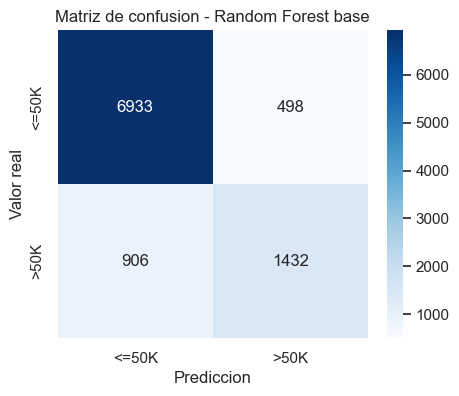

In [7]:
metricas_rf_base = evaluar_modelo(
    "Random Forest base",
    rf_base,
    X_test,
    y_test,
)

## 6. Ajuste básico de hiperparámetros

Se utiliza `GridSearchCV` para evaluar distintas combinaciones de hiperparámetros del Random Forest mediante validación cruzada.

La métrica de selección utilizada es `f1`, ya que el problema presenta desbalanceo de clases: la clase `>50K` representa una proporción menor del dataset. En este contexto, optimizar únicamente `accuracy` podría favorecer modelos que clasifiquen correctamente la clase mayoritaria `<=50K`, pero que fallen al detectar adecuadamente la clase positiva.

El F1-score combina precisión y recall, por lo que permite seleccionar un modelo que mantenga un equilibrio entre evitar falsos positivos y detectar correctamente los casos reales de ingresos superiores a 50K.

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini", "entropy"],
}


rf_grid = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)


print("\nMejores hiperparámetros encontrados:")
for param, valor in grid_search.best_params_.items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 promedio en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Mejores hiperparámetros encontrados:
  criterion: gini
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 200

Mejor F1 promedio en validación cruzada: 0.7060


## 7. Entrenar y evaluar el mejor Random Forest

`GridSearchCV` ya deja entrenado el mejor modelo usando los mejores parametros encontrados.

Resultados de Random Forest optimizado
Accuracy:  0.8383
Precision >50K: 0.6263
Recall >50K:    0.8037
F1 >50K:        0.7040

Classification report:
              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89      7431
        >50K       0.63      0.80      0.70      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.83      0.80      9769
weighted avg       0.86      0.84      0.84      9769



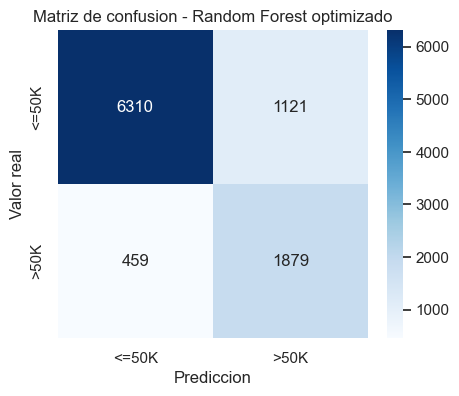

In [9]:
mejor_rf = grid_search.best_estimator_

metricas_rf_optimizado = evaluar_modelo(
    "Random Forest optimizado",
    mejor_rf,
    X_test,
    y_test,
)

## 8. Tabla de metricas del Random Forest optimizado
Se comparan ambas versiones del Random Forest para evidenciar el impacto del ajuste de hiperparámetros.

In [10]:
tabla_rf = pd.DataFrame([metricas_rf_base, metricas_rf_optimizado])
tabla_rf = tabla_rf.set_index("Modelo")
print("Comparación RF base vs RF optimizado:")
tabla_rf

Comparación RF base vs RF optimizado:


,Accuracy,Precision >50K,Recall >50K,F1 >50K,F1 macro,F1 weighted
Modelo,,,,,,
Random Forest base,0.856280,0.741969,0.612489,0.671040,0.789548,0.851331
Random Forest optimizado,0.838264,0.626333,0.803678,0.704009,0.796371,0.844523


## 9. Comparacion con los modelos de Fase 2

Primero se intenta cargar automaticamente `metricas_fase2.csv`, generado al ejecutar el notebook de Fase 2.

Si ese archivo todavia no existe, se crea una tabla editable para escribir las metricas manualmente.

En ese caso, reemplaza los valores `np.nan` por las metricas reales de:

- Perceptron
- Red neuronal 1 capa oculta
- Red neuronal 2 capas ocultas

In [13]:
try:
    metricas_fase2 = pd.read_csv("metricas_fase2.csv")
    print("Metricas de Fase 2 cargadas desde metricas_fase2.csv")
except FileNotFoundError:
    print("No se encontro metricas_fase2.csv. Completa manualmente esta tabla con los resultados de Fase 2.")
    metricas_fase2 = pd.DataFrame([
        {
            "Modelo": "Perceptron",
            "Accuracy": np.nan,
            "Precision >50K": np.nan,
            "Recall >50K": np.nan,
            "F1 >50K": np.nan,
            "F1 macro": np.nan,
            "F1 weighted": np.nan,
        },
        {
            "Modelo": "Red neuronal 1 capa oculta",
            "Accuracy": np.nan,
            "Precision >50K": np.nan,
            "Recall >50K": np.nan,
            "F1 >50K": np.nan,
            "F1 macro": np.nan,
            "F1 weighted": np.nan,
        },
        {
            "Modelo": "Red neuronal 2 capas ocultas",
            "Accuracy": np.nan,
            "Precision >50K": np.nan,
            "Recall >50K": np.nan,
            "F1 >50K": np.nan,
            "F1 macro": np.nan,
            "F1 weighted": np.nan,
        },
    ])

metricas_fase2

Metricas de Fase 2 cargadas desde metricas_fase2.csv


,Modelo,Accuracy,Precision >50K,Recall >50K,F1 >50K,F1 macro,F1 weighted
0,A – Perceptrón,0.8311,0.7082,0.5004,0.5865,0.7402,0.8203
1,B – 1 capa oculta (82 n.),0.8076,0.5654,0.8473,0.6782,0.7705,0.8186
2,C – 2 capas ocultas (2 n.),0.7999,0.5534,0.8494,0.6702,0.7633,0.8118


## 10. Tabla comparativa global

Se unen las métricas de los modelos neuronales de Fase 2 con las del Random Forest base y optimizado. La tabla se ordena por `F1 >50K` como criterio principal de evaluación.

**Criterio de decisión:** dado el desbalance de clases del dataset, el F1-score de la clase `>50K` es la métrica principal de comparación, ya que integra Precision y Recall para la clase minoritaria de mayor interés predictivo.

In [15]:
tabla_rf_completa = pd.DataFrame([metricas_rf_base, metricas_rf_optimizado])

tabla_comparativa = pd.concat(
    [metricas_fase2, tabla_rf_completa],
    ignore_index=True
)

tabla_comparativa_ordenada = tabla_comparativa.sort_values(
    by="F1 >50K",
    ascending=False,
    na_position="last",
).reset_index(drop=True)

print("Tabla comparativa global (ordenada por F1 >50K):")
tabla_comparativa_ordenada

Tabla comparativa global (ordenada por F1 >50K):


,Modelo,Accuracy,Precision >50K,Recall >50K,F1 >50K,F1 macro,F1 weighted
0,Random Forest optimizado,0.838264,0.626333,0.803678,0.704009,0.796371,0.844523
1,B – 1 capa oculta (82 n.),0.807600,0.565400,0.847300,0.678200,0.770500,0.818600
2,Random Forest base,0.856280,0.741969,0.612489,0.671040,0.789548,0.851331
3,C – 2 capas ocultas (2 n.),0.799900,0.553400,0.849400,0.670200,0.763300,0.811800
4,A – Perceptrón,0.831100,0.708200,0.500400,0.586500,0.740200,0.820300


## 11. Visualización comparativa

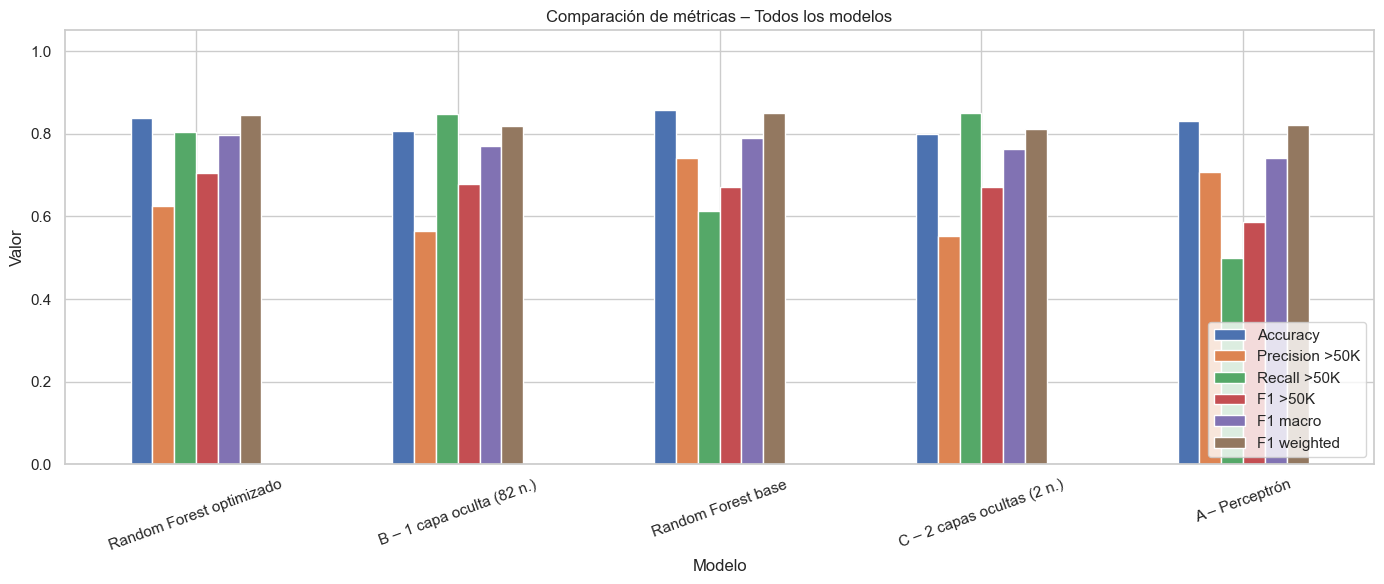

In [19]:
metricas_plot = ["Accuracy", "Precision >50K", "Recall >50K", "F1 >50K", "F1 macro", "F1 weighted"]

tabla_plot = tabla_comparativa_ordenada.set_index("Modelo")[metricas_plot]

ax = tabla_plot.plot(kind="bar", figsize=(14, 6), rot=20)
ax.set_title("Comparación de métricas – Todos los modelos")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Conclusión final

La conclusion toma el mejor modelo segun `F1 >50K`. Si todavia faltan las metricas de Fase 2, la comparacion se basa en los valores disponibles.

In [17]:
metricas_disponibles = tabla_comparativa_ordenada.dropna(subset=["F1 >50K"])

if metricas_disponibles.empty:
    print("No hay métricas disponibles para comparar.")
else:
    mejor = metricas_disponibles.iloc[0]
    modelo_b = metricas_disponibles[metricas_disponibles["Modelo"].str.contains("1 capa")]

    print("=" * 60)
    print("CONCLUSIÓN FINAL")
    print("=" * 60)
    print(f"\nMejor modelo global: {mejor['Modelo']}")
    print(f"  F1 >50K:   {mejor['F1 >50K']:.4f}")
    print(f"  Accuracy:  {mejor['Accuracy']:.4f}")
    print(f"  Recall:    {mejor['Recall >50K']:.4f}")
    print(f"  Precision: {mejor['Precision >50K']:.4f}")

    if not modelo_b.empty:
        f1_b  = modelo_b.iloc[0]["F1 >50K"]
        f1_rf = metricas_disponibles[metricas_disponibles["Modelo"] == "Random Forest optimizado"]["F1 >50K"].values
        if len(f1_rf) > 0:
            if f1_rf[0] > f1_b:
                print(f"\nEl Random Forest optimizado (F1={f1_rf[0]:.4f}) supera al Modelo B (F1={f1_b:.4f}).")
                print("El modelo clásico es el mejor modelo global del proyecto.")
            else:
                print(f"\nEl Modelo B (F1={f1_b:.4f}) supera al Random Forest optimizado (F1={f1_rf[0]:.4f}).")
                print("La red neuronal de una capa oculta sigue siendo el mejor modelo global.")

CONCLUSIÓN FINAL

Mejor modelo global: Random Forest optimizado
  F1 >50K:   0.7040
  Accuracy:  0.8383
  Recall:    0.8037
  Precision: 0.6263

El Random Forest optimizado (F1=0.7040) supera al Modelo B (F1=0.6782).
El modelo clásico es el mejor modelo global del proyecto.
